# Sparsity and Optimization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Baseline Model

First, we establish a baseline model(Deberta-v3) with pretrained weights.

## Installing dependencies

In [ ]:
!pip install -q bitsandbytes datasets accelerate loralib evaluate
!pip install -q git+https://github.com/huggingface/peft.git git+https://github.com/huggingface/transformers.git
!pip install --upgrade "torchao>0.16.0"

## Setting up data for the CoLA task

In [ ]:
!git clone https://github.com/nyu-mll/GLUE-baselines.git
!python GLUE-baselines/download_glue_data.py --data_dir glue_data --tasks CoLA
!cp -r glue_data/CoLA "/content/drive/My Drive/my_dataset_folder"

## Loading the base model

In [ ]:
import torch
import os
import bitsandbytes as bnb

from transformers import AutoTokenizer,AutoConfig,AutoModelForSequenceClassification

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_id = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(model_id)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_id,num_labels=2,dtype=torch.float32).to(device)
print(model)

## Creating the tokenized dataset

In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader

# Load the CoLA dataset from the folder you downloaded
dataset = load_dataset('csv', data_files={
    'train': '/content/drive/MyDrive/glue_data/CoLA/train.tsv',
    'validation': '/content/drive/MyDrive/glue_data/CoLA/dev.tsv'
}, delimiter='\t', column_names=['sentence_source', 'labels', 'label_notes', 'sentence'])

def tokenize_fn(examples):
    return tokenizer(examples['sentence'], truncation=True, padding='max_length', max_length=128)

# Tokenize and format for PyTorch
tokenized_datasets = dataset.map(tokenize_fn, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['sentence_source', 'label_notes', 'sentence'])
tokenized_datasets.set_format("torch")

## Number of trainable parameters

In [ ]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [ ]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
print_trainable_parameters(model)

## Fully Fine-Tuning the base model

In [ ]:
import numpy as np
import evaluate
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

# Load the MCC metric
mcc_metric = evaluate.load("matthews_correlation")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Get the predicted class (0 or 1) by finding the max logit
    predictions = np.argmax(logits, axis=-1)
    # Calculate MCC
    return mcc_metric.compute(predictions=predictions, references=labels)

In [ ]:
import time
import torch
from transformers import TrainerCallback

class PerformanceMetricsCallback(TrainerCallback):

    def __init__(self):
        self.epoch_times = []
        self.peak_vram = []

    def on_epoch_begin(self, args, state, control, **kwargs):
        self.start_time = time.time()
        torch.cuda.reset_peak_memory_stats()

    def on_epoch_end(self, args, state, control, **kwargs):
        epoch_time = time.time() - self.start_time
        peak_mem = torch.cuda.max_memory_allocated() / 1024**3

        self.epoch_times.append(epoch_time)
        self.peak_vram.append(peak_mem)

        print(f"Epoch Time: {epoch_time:.2f}s")
        print(f"Peak VRAM: {peak_mem:.2f} GB")

## Setting up the Trainer

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import torch

results = []

def run_experiment(
    method_name,
    model,
    tokenizer,
    train_dataset,
    eval_dataset,
    compute_metrics,
    output_dir,
    batch_size=32,
    learning_rate=4e-5,
    num_epochs=3,
    weight_decay=0.01,
    seed=42
):

    torch.manual_seed(seed)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    perf_callback = PerformanceMetricsCallback()

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        fp16=False,
        num_train_epochs=num_epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        logging_steps=50,
        seed=seed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[perf_callback]
    )

    # Train
    trainer.train()

    # Final evaluation
    eval_results = trainer.evaluate()

    # Store results
    results.append({
        "Method": method_name,
        "MCC": eval_results["eval_matthews_correlation"],
        "Peak VRAM (GB)": max(perf_callback.peak_vram),
        "Train Time (s)": sum(perf_callback.epoch_times),
        "Trainable Params": count_trainable_params(model)
    })

    return trainer

In [ ]:
trainer_ft = run_experiment(
    method_name='full_finetuning',
    model=model,
    tokenizer=tokenizer,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    output_dir="./results-ft",
)

Epoch,Training Loss,Validation Loss,Matthews Correlation
1,0.322010,0.321023,0.693359
2,0.184053,0.424912,0.661075
3,0.098460,0.511092,0.672719


Epoch Time: 222.21s
Peak VRAM: 8.72 GB


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch Time: 225.23s
Peak VRAM: 8.72 GB


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch Time: 214.20s
Peak VRAM: 8.72 GB


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Matthews Correlation
0.098460,0.321023,3,0.693359


## Running inference on the base model

In [ ]:
def predict_acceptability(sentence,model):
    # Prepare the input
    inputs = tokenizer(sentence, return_tensors="pt")

    # Move inputs to the same device as the model (GPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Get prediction
    with torch.no_grad():
        logits = model(**inputs).logits

    # Convert logits to class (0 = Unacceptable, 1 = Acceptable)
    prediction = torch.argmax(logits, dim=-1).item()

    print(f"Sentence: {sentence}")
    print(f"Result: {'Acceptable' if prediction == 1 else 'Unacceptable'}")
    print("-" * 30)

In [ ]:
predict_acceptability("Barcelona is in Spain.",model) # Correct
predict_acceptability("the boy and is the king.",model) # Incorrect

Now, we experiment with some other parameter efficient fine tuning methods and see how they hold up compared to full fine-tuning.

# LoRA

## Loading the pretrained model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_id,num_labels=2,dtype=torch.float32).to(device)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.den

## Number of trainable parameters

In [ ]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query_proj","key_proj","value_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS"
)

model_lora = get_peft_model(model, config)
print_trainable_parameters(model_lora)

trainable params: 443906 || all params: 184867588 || trainable%: 0.24012105356186073


## Fine-tuning by training only the LoRA Adapters

In [ ]:
trainer_lora = run_experiment(
    method_name='LoRA_r8',
    model=model_lora,
    tokenizer=tokenizer,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    output_dir="./results-lora_r8",
    num_epochs=6
)

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Matthews Correlation
1,0.569704,0.538971,0.000000
2,0.393010,0.411987,0.575804
3,0.364705,0.392983,0.620724
4,0.358720,0.407057,0.605866
5,0.356244,0.392999,0.620684
6,0.362646,0.392528,0.623177


Epoch Time: 188.31s
Peak VRAM: 7.00 GB
Epoch Time: 183.88s
Peak VRAM: 7.00 GB
Epoch Time: 183.88s
Peak VRAM: 7.00 GB
Epoch Time: 183.61s
Peak VRAM: 7.00 GB
Epoch Time: 183.60s
Peak VRAM: 7.00 GB
Epoch Time: 183.55s
Peak VRAM: 7.00 GB


Training Loss,Validation Loss,Epoch,Matthews Correlation
0.362646,0.392528,6,0.623177


## Inference

In [ ]:
predict_acceptability("Barcelona is in Spain.",model_lora) # Correct
predict_acceptability("the boy and the is king.",model_lora) # Incorrect

Sentence: Barcelona is in Spain.
Result: ✅ Acceptable
------------------------------
Sentence: the boy and the is king.
Result: ❌ Unacceptable
------------------------------


## Another version with a higher rank

In [ ]:
from peft import LoraConfig, get_peft_model

model = AutoModelForSequenceClassification.from_pretrained(model_id,num_labels=2,dtype=torch.float32).to(device)

config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query_proj","key_proj","value_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS"
)

model_lora = get_peft_model(model, config)
print_trainable_parameters(model_lora)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

trainable params: 886274 || all params: 185309956 || trainable%: 0.47826572253894445


In [ ]:
trainer_lora = run_experiment(
    method_name='LoRA_r16',
    model=model_lora,
    tokenizer=tokenizer,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    output_dir="./results-lora_r16",
)

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Matthews Correlation
1,0.549788,0.509963,0.000000
2,0.412422,0.455963,0.580748
3,0.391781,0.442138,0.598101


Epoch Time: 180.68s
Peak VRAM: 7.01 GB
Epoch Time: 175.17s
Peak VRAM: 7.01 GB
Epoch Time: 175.77s
Peak VRAM: 7.01 GB


Training Loss,Validation Loss,Epoch,Matthews Correlation
0.391781,0.442138,3,0.598101


Doesn't seem to improve performance, suggesting that the budget is overkill.

# AdaLoRA

In [ ]:
from peft import AdaLoraConfig, get_peft_model

model = AutoModelForSequenceClassification.from_pretrained(model_id,num_labels=2,dtype=torch.float32).to(device)

config = AdaLoraConfig(
    task_type="SEQ_CLS",

    init_r=16,            # initial rank
    target_r=8,           # average target rank

    lora_alpha=16,

    target_modules=[
        "query_proj",
        "key_proj",
        "value_proj"
    ],

    lora_dropout=0.05,

    total_step=2144,      # IMPORTANT
    tinit=200,            # warmup before pruning
    tfinal=1800,           # stop adaptation near end
    deltaT=10             # rank reallocation interval
)

model_adalora = get_peft_model(model, config)
print_trainable_parameters(model_adalora)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier

trainable params: 886850 || all params: 185310568 || trainable%: 0.47857497258332293


In [ ]:
trainer_lora = run_experiment(
    method_name='AdaLoRA_r16',
    model=model_adalora,
    tokenizer=tokenizer,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    output_dir="./results-adalora_r16",
    learning_rate=3e-4,
    num_epochs=8
)

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Matthews Correlation
1,0.602427,0.608451,0.000000
2,0.488923,0.470249,0.514837
3,0.431217,0.425230,0.563188
4,0.411275,0.420448,0.571799
5,0.415964,0.401339,0.593405
6,0.398842,0.390989,0.593202
7,0.386720,0.390119,0.598333
8,0.366196,0.392205,0.600954


Epoch Time: 202.29s
Peak VRAM: 7.01 GB
Epoch Time: 194.56s
Peak VRAM: 7.01 GB
Epoch Time: 194.62s
Peak VRAM: 7.01 GB
Epoch Time: 194.84s
Peak VRAM: 7.01 GB
Epoch Time: 194.47s
Peak VRAM: 7.01 GB
Epoch Time: 194.35s
Peak VRAM: 7.01 GB
Epoch Time: 194.40s
Peak VRAM: 7.01 GB
Epoch Time: 194.75s
Peak VRAM: 7.01 GB


Training Loss,Validation Loss,Epoch,Matthews Correlation
0.366196,0.390119,8,0.598333


# SoRA

We use the official SoRA repository.

In [ ]:
!git clone https://github.com/TsinghuaC3I/SoRA.git

In [ ]:
pip install -r SoRA/requirements.txt

## Additional requirements

In [ ]:
!pip install transformers==4.34.0 datasets==2.14.6 peft==0.5.0 huggingface-hub==0.17.3 accelerate==0.24.1

In [ ]:
!pip install git+https://github.com/thunlp/OpenDelta.git

In [ ]:
!pip install "numpy<2.0.0"

In [ ]:
%cd ..
!mkdir results

/content/SoRA


In [ ]:
%cd scripts

/content/SoRA/scripts


## Running SoRA

In [ ]:
!bash run_glue_sora_no_schedule.sh

In [ ]:
import json
import glob
import os

# Find all trainer_state.json files in your results folder
state_files = glob.glob("/content/SoRA/results/**/trainer_state.json", recursive=True)

if not state_files:
    print("No training state found yet. Let it finish at least 1 epoch!")
else:
    # Grab the most recently modified run directory
    latest_file = max(state_files, key=os.path.getmtime)
    print(f"Reading live metrics from: {latest_file}\n")

    with open(latest_file, "r") as f:
        state = json.load(f)

    # Extract and print only the evaluation logs
    for log in state.get("log_history", []):
        if "eval_matthews_correlation" in log:
            epoch = log.get('epoch', '?')
            mcc = log['eval_matthews_correlation']
            loss = log.get('eval_loss', '?')
            print(f"Epoch {epoch}: MCC = {mcc:.4f} | Eval Loss = {loss:.4f}")

Reading live metrics from: /content/SoRA/results/cola_lora_r_8_lambda_10_lambda2_3e-4_lr_8e-4_epoch_8_bsz_8_seed_0/checkpoint-4000/trainer_state.json

Epoch 0.47: MCC = 0.4801 | Eval Loss = 8.0792
Epoch 0.94: MCC = 0.5953 | Eval Loss = 5.8784
Epoch 1.4: MCC = 0.6363 | Eval Loss = 3.8557
Epoch 1.87: MCC = 0.5812 | Eval Loss = 2.6913
Epoch 2.34: MCC = 0.6413 | Eval Loss = 1.7659
Epoch 2.81: MCC = 0.6738 | Eval Loss = 1.2023
Epoch 3.27: MCC = 0.6091 | Eval Loss = 1.0379
Epoch 3.74: MCC = 0.6387 | Eval Loss = 0.9122


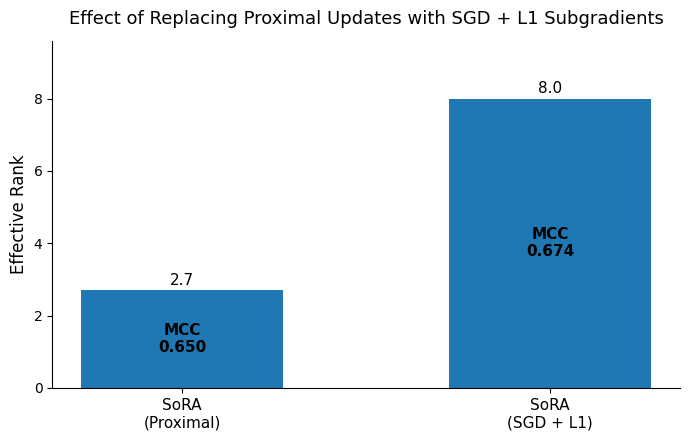

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods = ["SoRA\n(Proximal)", "SoRA\n(SGD + L1)"]

# Replace with your final values
effective_rank = [2.7, 8.0]
mcc = [0.650, 0.674]

x = np.arange(len(methods))

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    x,
    effective_rank,
    width=0.55
)

# Rank labels on bars
for bar, rank in zip(bars, effective_rank):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        rank + 0.15,
        f"{rank:.1f}",
        ha="center",
        fontsize=11
    )

# MCC labels inside bars
for bar, score in zip(bars, mcc):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        f"MCC\n{score:.3f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)

ax.set_ylabel("Effective Rank", fontsize=12)
ax.set_title(
    "Effect of Replacing Proximal Updates with SGD + L1 Subgradients",
    fontsize=13,
    pad=12
)

ax.set_ylim(0, max(effective_rank) * 1.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("proximal_vs_sgd_rank.png", dpi=300, bbox_inches="tight")
plt.show()

# Deep dive inside SoRA

## Numpy implementation of SGD

In [ ]:
import numpy as np

# Hyperparameters
lr = 0.05
lam = 0.5
steps = 100

# Target vector
w = np.array([3.0, -2.0, 0.5, 0.1, -0.05])

# Initial gate vector
g_numpy = np.array([0.5, -1.0, 0.3, -0.2, 0.05])

for step in range(steps):

    # Forward Pass
    loss_task = 0.5 * np.sum((g_numpy - w) ** 2)

    # Backward Pass
    grad_task = g_numpy - w

    # L1 subgradient
    grad_l1 = lam * np.sign(g_numpy)

    # Total gradient
    grad = grad_task + grad_l1

    # SGD Update
    g_numpy -= lr * grad

print("Final gates:")
print(g_numpy)

print("Final loss:")
print(loss_task)

Final gates:
[ 2.48815894e+00 -1.49703974e+00  1.77615877e-03  1.67569658e-02
  1.93159427e-02]
Final loss:
0.38951883206724436


## PyTorch implementation of SGD

In [ ]:
import torch

# Hyperparameters
lr = 0.05
lam = 0.5
steps = 100

w = torch.tensor(
    [3.0, -2.0, 0.5, 0.1, -0.05],
    dtype=torch.float64
)

g_torch = torch.tensor(
    [0.5, -1.0, 0.3, -0.2, 0.05],
    dtype=torch.float64,
    requires_grad=True
)

for step in range(steps):

    # Forward Pass
    loss_task = 0.5 * torch.sum((g_torch - w) ** 2)

    # Backward Pass
    loss_task.backward()

    with torch.no_grad():

        grad = g_torch.grad + lam * torch.sign(g_torch)

        # SGD + L1 update
        g_torch -= lr * grad

    g_torch.grad.zero_()

print("Final gates:")
print(g_torch)

print("Final loss:")
print(loss_task.item())

Final gates:
tensor([ 2.4882e+00, -1.4970e+00,  1.7762e-03,  1.6757e-02,  1.9316e-02],
       dtype=torch.float64, requires_grad=True)
Final loss:
0.38951883206724436


## Comparison

In [ ]:
print(np.max(np.abs(
    g_numpy -
    g_torch.detach().numpy()
)))

0.0


This shows that both the implementations are correct.